# AID843 – Assignment 2: Temporal Analysis
### Top 5 European Leagues + World Cup 2018
**Tasks:** Preprocessing → Decomposition → Autocorrelation & Stationarity → ARIMA + Linear Regression Forecasting

---
## BLOCK 1: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Temporal stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Linear regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

print('All imports successful')


All imports successful


---
## BLOCK 2: Load & Merge Data
> **Key idea:** Events have no dates. Matches have `dateutc` and `gameweek`. We join them on `matchId`/`wyId` to get a dated, gameweek-ordered time series.

In [2]:
# ── League config ─────────────────────────────────────────────────────────────
LEAGUES = {
    'England'    : ('events_England.csv',    'matches_England.csv'),
    'Spain'      : ('events_Spain.csv',      'matches_Spain.csv'),
    'Italy'      : ('events_Italy.csv',      'matches_Italy.csv'),
    'Germany'    : ('events_Germany.csv',    'matches_Germany.csv'),
    'France'     : ('events_France.csv',     'matches_France.csv'),
    'World_Cup'  : ('events_World_Cup.csv',  'matches_World_Cup.csv'),
}

def load_league(events_file, matches_file, league_name):
    """Load events + matches, join on matchId, return clean DataFrame."""
    ev = pd.read_csv(events_file)
    mt = pd.read_csv(matches_file)

    # Keep only what we need from matches
    mt = mt[['wyId', 'dateutc', 'gameweek',
             'team1.score', 'team2.score']].copy()
    mt.rename(columns={'wyId': 'matchId'}, inplace=True)
    mt['date'] = pd.to_datetime(mt['dateutc'], utc=True).dt.tz_localize(None)
    mt['total_goals'] = mt['team1.score'] + mt['team2.score']

    # Merge events with match dates
    df = ev.merge(mt[['matchId','date','gameweek','total_goals']], on='matchId', how='left')
    df['league'] = league_name
    return df, mt

# Load all leagues
all_events = []
all_matches = {}

for league, (ev_file, mt_file) in LEAGUES.items():
    df, mt = load_league(ev_file, mt_file, league)
    all_events.append(df)
    all_matches[league] = mt
    print(f'{league:12s}: {len(df):>7,} events | {len(mt):>3} matches')

full_df = pd.concat(all_events, ignore_index=True)
print(f'\nTotal events across all leagues: {len(full_df):,}')


England     : 643,090 events | 380 matches
Spain       : 628,550 events | 380 matches
Italy       : 647,300 events | 380 matches
Germany     : 519,357 events | 306 matches
France      : 632,737 events | 380 matches
World_Cup   : 101,756 events |  64 matches

Total events across all leagues: 3,172,790


---
## BLOCK 3: Build Time Series
We build **two types of time series** per league:
1. **Gameweek series** – shots/events per gameweek (ordered match sequence)
2. **Calendar date series** – daily/weekly aggregation using actual match dates

For **within-match** analysis we use `eventSec` (seconds elapsed in match).

In [3]:
# ── 3a: Shots per gameweek per league ────────────────────────────────────────
def build_gameweek_series(league_name, event_type='Shot'):
    """Count events of a given type per gameweek for a league."""
    sub = full_df[(full_df['league'] == league_name) &
                  (full_df['eventName'] == event_type)]
    ts = sub.groupby('gameweek').size().reset_index(name='count')
    ts = ts.sort_values('gameweek').reset_index(drop=True)
    return ts

# ── 3b: Match-level stats per league (for date-based series) ─────────────────
def build_match_series(league_name):
    """One row per match: date, total shots, total passes, total goals."""
    sub = full_df[full_df['league'] == league_name]
    shots  = sub[sub['eventName']=='Shot'].groupby('matchId').size().rename('shots')
    passes = sub[sub['eventName']=='Pass'].groupby('matchId').size().rename('passes')
    duels  = sub[sub['eventName']=='Duel'].groupby('matchId').size().rename('duels')

    mt = all_matches[league_name][['matchId','date','gameweek','total_goals']].copy()
    mt = mt.join(shots,  on='matchId').join(passes, on='matchId').join(duels, on='matchId')
    mt = mt.sort_values('date').reset_index(drop=True)
    mt[['shots','passes','duels']] = mt[['shots','passes','duels']].fillna(0)
    return mt

# Preview England
eng_gw = build_gameweek_series('England')
eng_mt = build_match_series('England')

print('England gameweek series (shots per gameweek):')
print(eng_gw.head(10))
print('\nEngland match series (first 5 matches):')
print(eng_mt[['date','gameweek','shots','passes','total_goals']].head())


England gameweek series (shots per gameweek):
   gameweek  count
0         1    236
1         2    236
2         3    261
3         4    228
4         5    242
5         6    207
6         7    236
7         8    214
8         9    224
9        10    199

England match series (first 5 matches):
                 date  gameweek  shots  passes  total_goals
0 2017-08-11 18:45:00         1     34     836            7
1 2017-08-12 11:30:00         1     20     824            6
2 2017-08-12 14:00:00         1     29     837            0
3 2017-08-12 14:00:00         1     24     812            5
4 2017-08-12 14:00:00         1     24     831            1


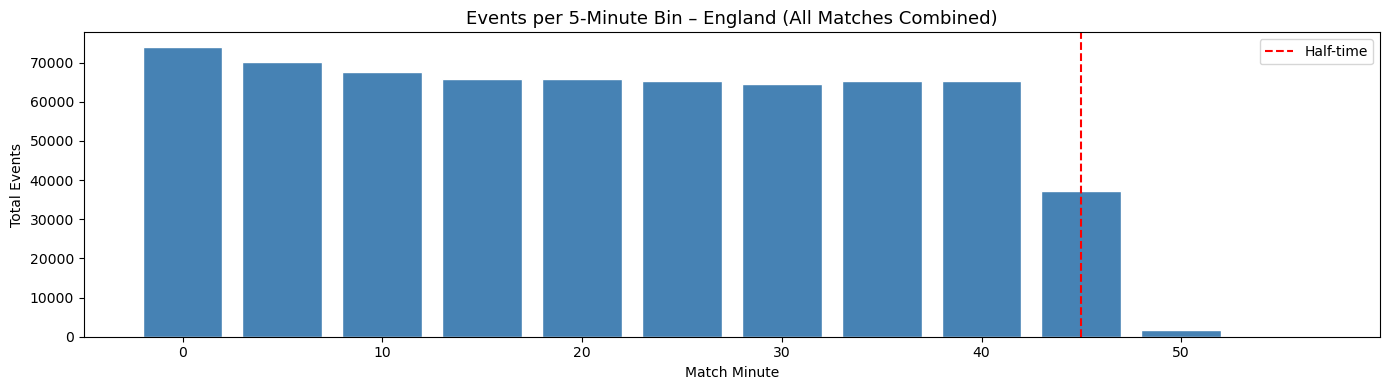

Within-match temporal pattern shown above.


In [4]:
# ── 3c: Within-match temporal series (England) ───────────────────────────────
# eventSec = seconds elapsed. Split into 5-minute bins across the 90-min match.
eng_ev = full_df[(full_df['league']=='England') &
                 (full_df['eventSec'].notna()) &
                 (full_df['eventSec'] >= 0)].copy()

# Convert to minutes, clip to 0-95 (some added time)
eng_ev['minute'] = (eng_ev['eventSec'] / 60).clip(0, 95).astype(int)
eng_ev['min_bin'] = (eng_ev['minute'] // 5) * 5  # 5-minute bins

within_match = eng_ev.groupby('min_bin').size().reset_index(name='event_count')

plt.figure(figsize=(14, 4))
plt.bar(within_match['min_bin'], within_match['event_count'], width=4, color='steelblue', edgecolor='white')
plt.axvline(45, color='red', linestyle='--', label='Half-time')
plt.title('Events per 5-Minute Bin – England (All Matches Combined)', fontsize=13)
plt.xlabel('Match Minute')
plt.ylabel('Total Events')
plt.legend()
plt.tight_layout()
plt.show()
print('Within-match temporal pattern shown above.')


---
## BLOCK 4: Exploratory Temporal Visualizations

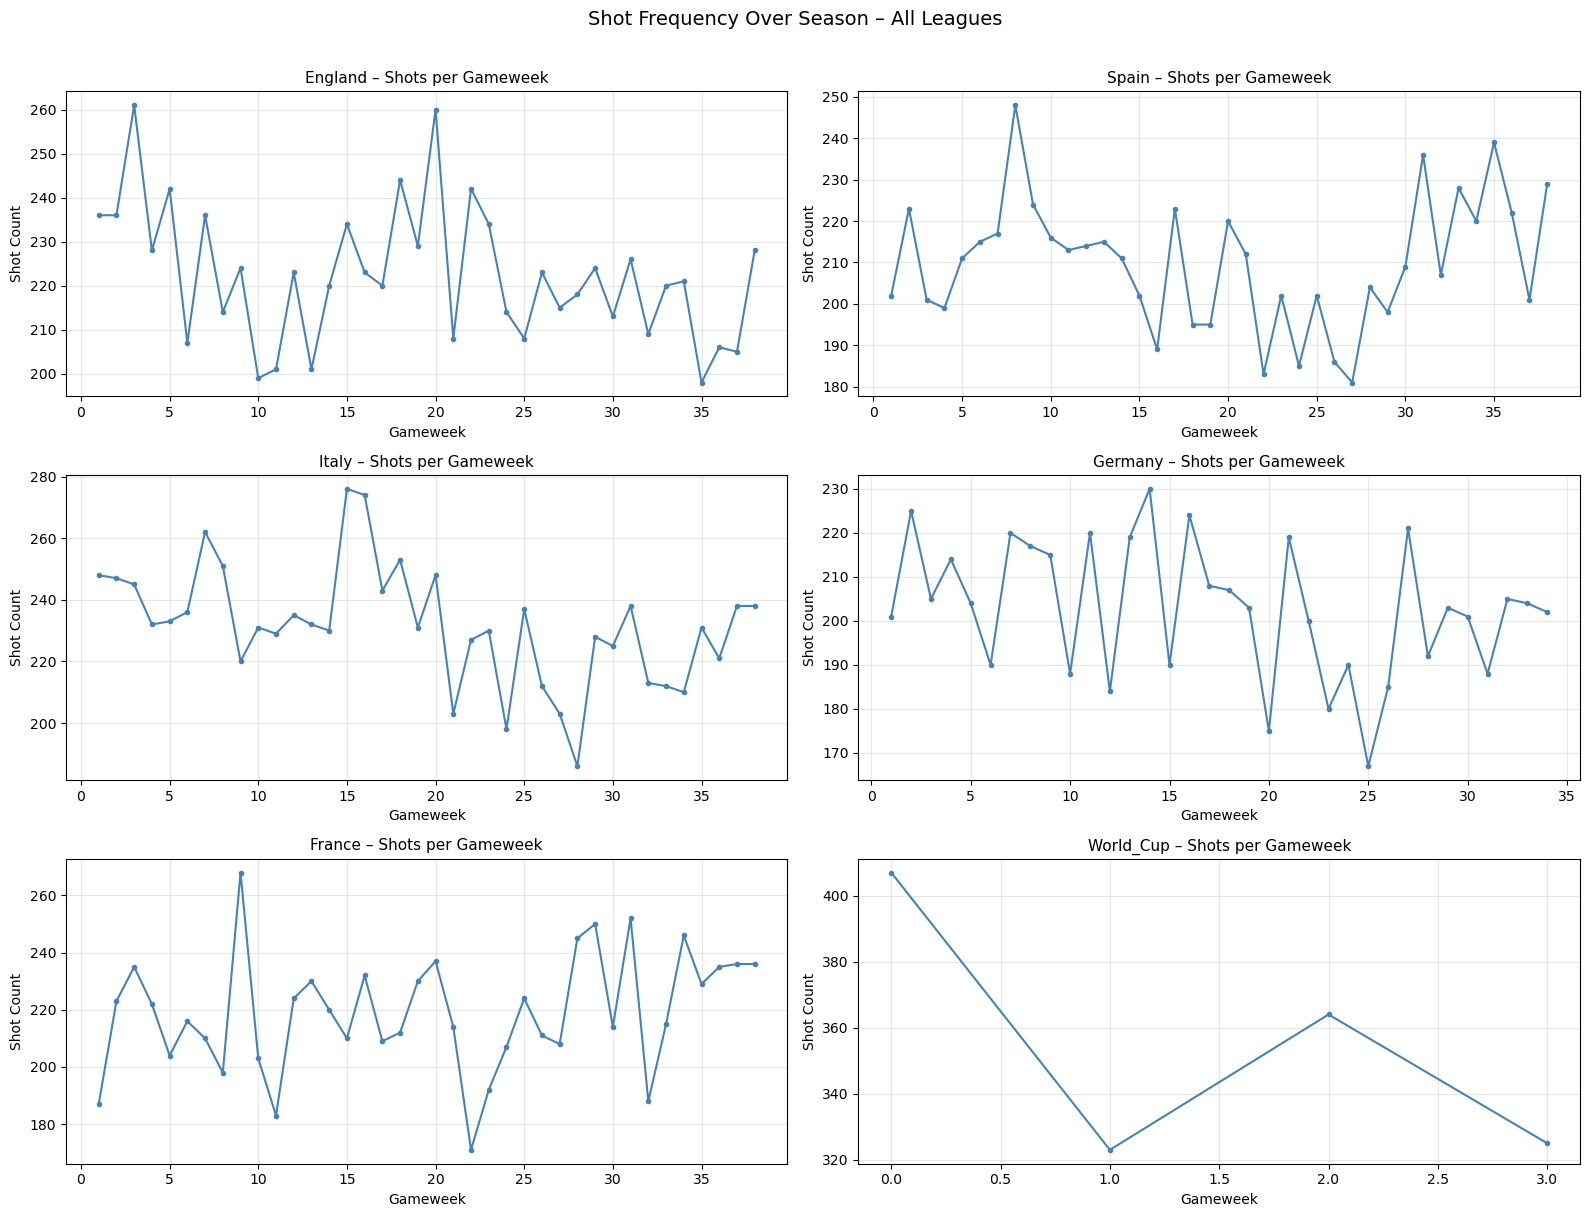

In [5]:
# ── 4a: Shots per gameweek for all leagues ────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, league in zip(axes, LEAGUES.keys()):
    ts = build_gameweek_series(league)
    ax.plot(ts['gameweek'], ts['count'], marker='o', markersize=3,
            linewidth=1.5, color='steelblue')
    ax.set_title(f'{league} – Shots per Gameweek', fontsize=11)
    ax.set_xlabel('Gameweek')
    ax.set_ylabel('Shot Count')
    ax.grid(alpha=0.3)

plt.suptitle('Shot Frequency Over Season – All Leagues', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


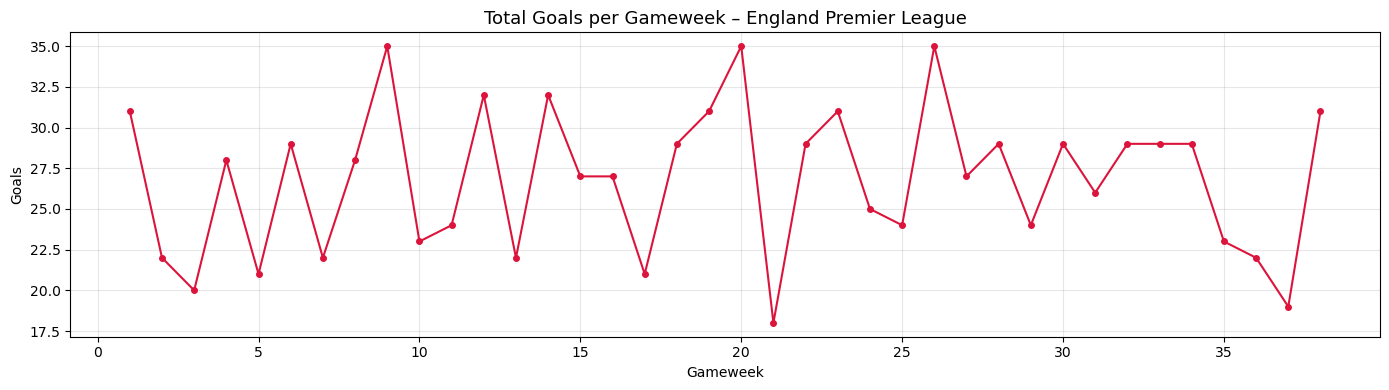

In [6]:
# ── 4b: Total goals per gameweek (England) ───────────────────────────────────
eng_goals = eng_mt.groupby('gameweek')['total_goals'].sum().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(eng_goals['gameweek'], eng_goals['total_goals'],
         marker='o', markersize=4, color='crimson')
plt.title('Total Goals per Gameweek – England Premier League', fontsize=13)
plt.xlabel('Gameweek')
plt.ylabel('Goals')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


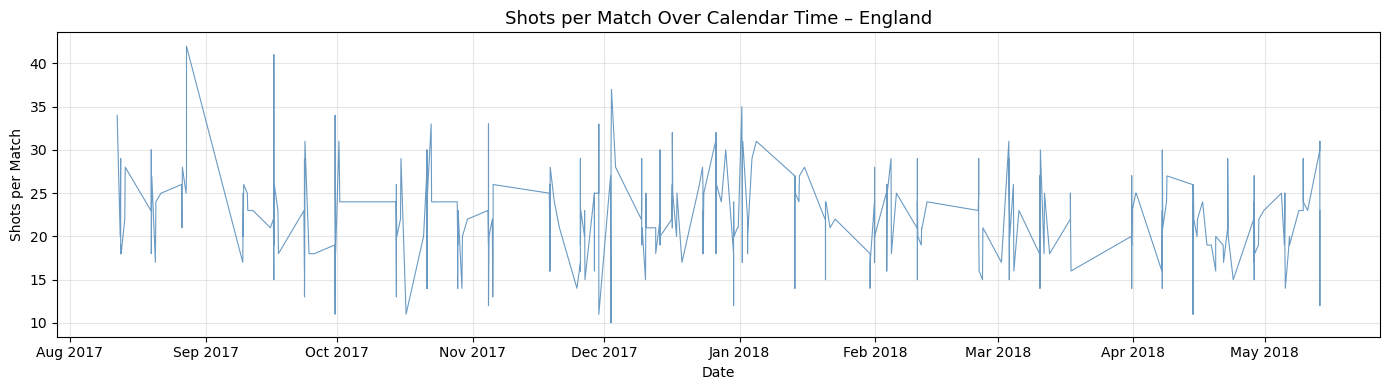

In [7]:
# ── 4c: Match-level shots over calendar time (England) ───────────────────────
plt.figure(figsize=(14, 4))
plt.plot(eng_mt['date'], eng_mt['shots'], linewidth=0.8, color='steelblue', alpha=0.8)
plt.title('Shots per Match Over Calendar Time – England', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Shots per Match')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


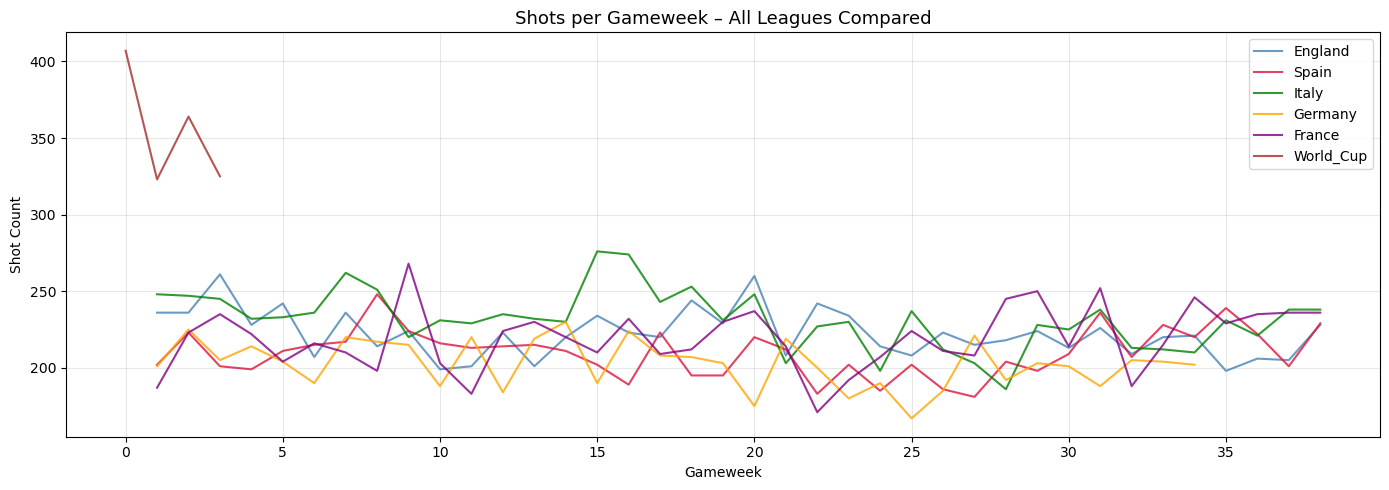

In [8]:
# ── 4d: Cross-league shots per gameweek comparison ───────────────────────────
plt.figure(figsize=(14, 5))
colors = ['steelblue','crimson','green','orange','purple','brown']
for league, color in zip(LEAGUES.keys(), colors):
    ts = build_gameweek_series(league)
    plt.plot(ts['gameweek'], ts['count'], label=league, linewidth=1.5,
             color=color, alpha=0.8)
plt.title('Shots per Gameweek – All Leagues Compared', fontsize=13)
plt.xlabel('Gameweek')
plt.ylabel('Shot Count')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


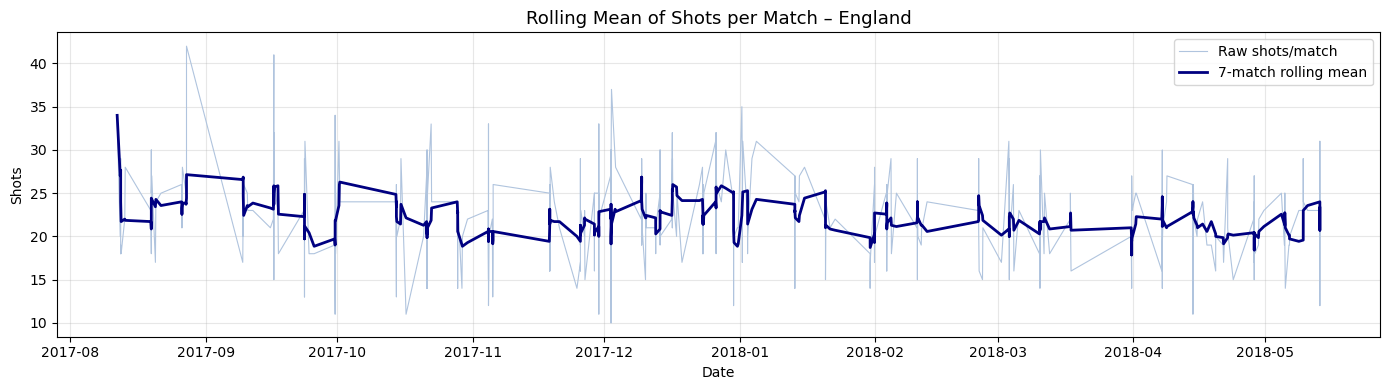

In [9]:
# ── 4e: Rolling mean (7-match window) – England shots ───────────────────────
eng_mt_sorted = eng_mt.sort_values('date').copy()
eng_mt_sorted['rolling_shots'] = eng_mt_sorted['shots'].rolling(7, min_periods=1).mean()

plt.figure(figsize=(14, 4))
plt.plot(eng_mt_sorted['date'], eng_mt_sorted['shots'],
         color='lightsteelblue', linewidth=0.8, label='Raw shots/match')
plt.plot(eng_mt_sorted['date'], eng_mt_sorted['rolling_shots'],
         color='navy', linewidth=2, label='7-match rolling mean')
plt.title('Rolling Mean of Shots per Match – England', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Shots')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## BLOCK 5: Task 1 – Preprocessing for Temporal Analysis
### Decomposition, Detrending, Deseasonalization

In [10]:
# ── 5a: Build clean gameweek time series for decomposition ───────────────────
# Use England shots per gameweek as primary series
gw_ts = build_gameweek_series('England', 'Shot')

# Fill missing gameweeks with 0 (in case any gameweek had no shots recorded)
all_gw = pd.DataFrame({'gameweek': range(gw_ts['gameweek'].min(),
                                          gw_ts['gameweek'].max()+1)})
gw_ts = all_gw.merge(gw_ts, on='gameweek', how='left').fillna(0)
y = gw_ts['count'].values

print(f'Series length: {len(y)} gameweeks')
print(f'Min: {y.min():.0f} | Max: {y.max():.0f} | Mean: {y.mean():.2f}')


Series length: 38 gameweeks
Min: 198 | Max: 261 | Mean: 222.37


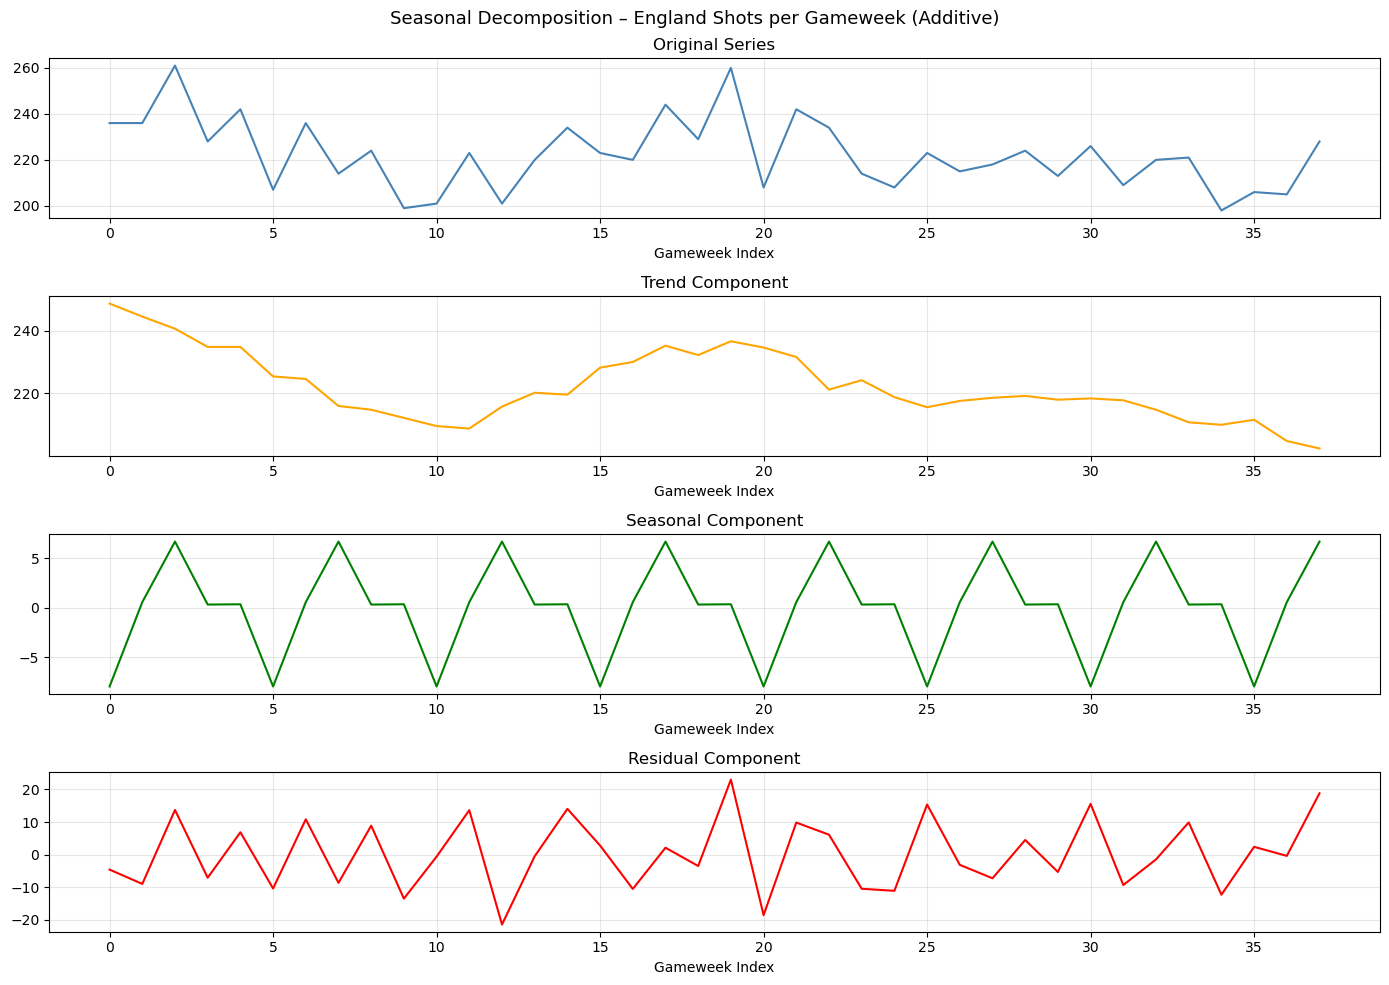

In [11]:
# ── 5b: Seasonal Decomposition (additive model) ───────────────────────────────
# period=5 means we look for patterns repeating every ~5 gameweeks
decomp = seasonal_decompose(y, model='additive', period=5, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes[0].plot(y, color='steelblue');           axes[0].set_title('Original Series');     axes[0].grid(alpha=0.3)
axes[1].plot(decomp.trend, color='orange');   axes[1].set_title('Trend Component');     axes[1].grid(alpha=0.3)
axes[2].plot(decomp.seasonal, color='green'); axes[2].set_title('Seasonal Component');  axes[2].grid(alpha=0.3)
axes[3].plot(decomp.resid, color='red');      axes[3].set_title('Residual Component');  axes[3].grid(alpha=0.3)
for ax in axes:
    ax.set_xlabel('Gameweek Index')
plt.suptitle('Seasonal Decomposition – England Shots per Gameweek (Additive)', fontsize=13)
plt.tight_layout()
plt.show()


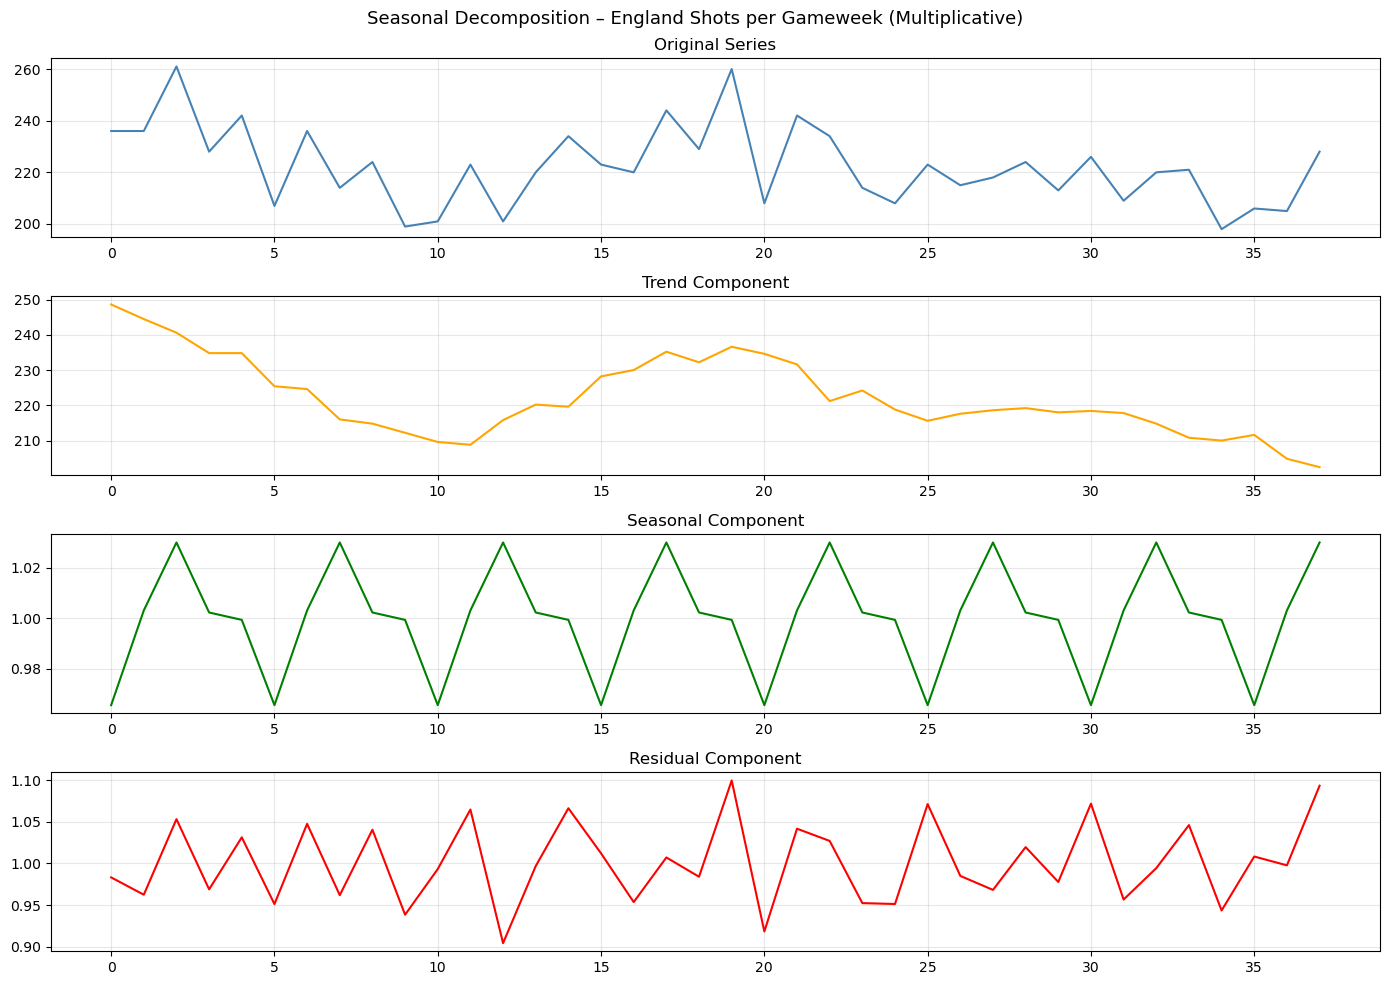

In [12]:
# ── 5c: Multiplicative decomposition ─────────────────────────────────────────
# Only works if all values > 0
y_pos = np.where(y == 0, 0.1, y)  # replace any zeros
decomp_mult = seasonal_decompose(y_pos, model='multiplicative', period=5,
                                  extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes[0].plot(y_pos, color='steelblue');              axes[0].set_title('Original Series')
axes[1].plot(decomp_mult.trend, color='orange');     axes[1].set_title('Trend Component')
axes[2].plot(decomp_mult.seasonal, color='green');   axes[2].set_title('Seasonal Component')
axes[3].plot(decomp_mult.resid, color='red');        axes[3].set_title('Residual Component')
for ax in axes:
    ax.grid(alpha=0.3)
plt.suptitle('Seasonal Decomposition – England Shots per Gameweek (Multiplicative)', fontsize=13)
plt.tight_layout()
plt.show()


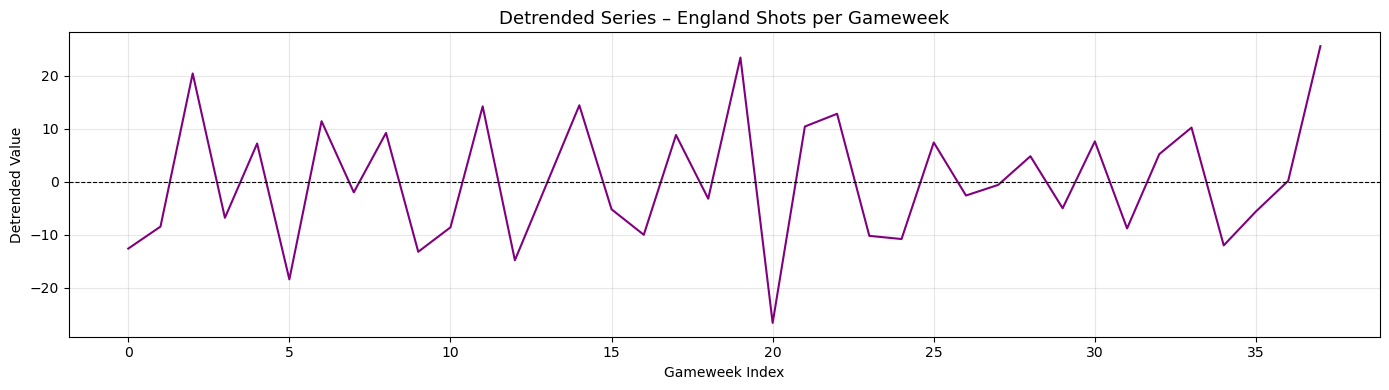

In [13]:
# ── 5d: Detrending ────────────────────────────────────────────────────────────
trend = decomp.trend
detrended = y - trend

plt.figure(figsize=(14, 4))
plt.plot(detrended, color='purple', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Detrended Series – England Shots per Gameweek', fontsize=13)
plt.xlabel('Gameweek Index')
plt.ylabel('Detrended Value')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


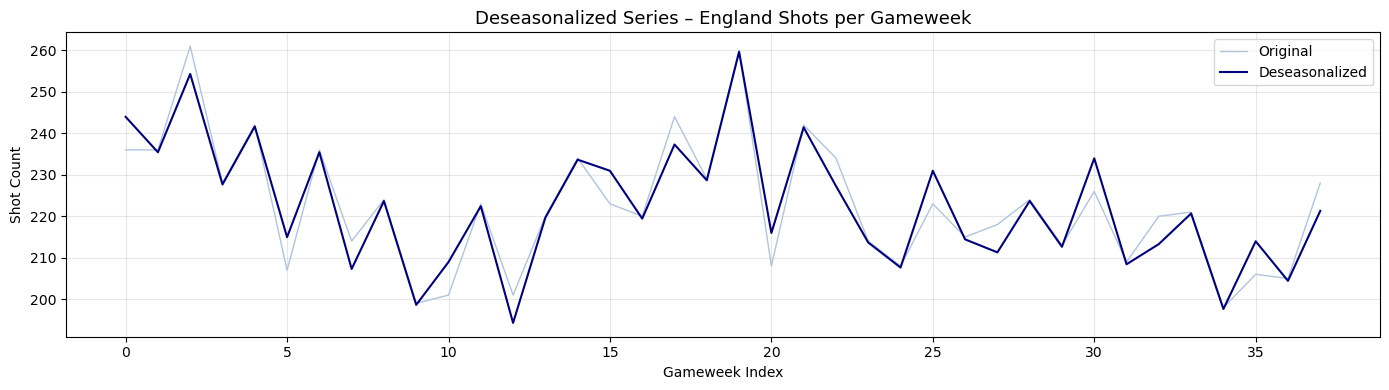

In [14]:
# ── 5e: Deseasonalization ────────────────────────────────────────────────────
seasonal = decomp.seasonal
deseasonalized = y - seasonal

plt.figure(figsize=(14, 4))
plt.plot(y, color='lightsteelblue', label='Original', linewidth=1)
plt.plot(deseasonalized, color='navy', label='Deseasonalized', linewidth=1.5)
plt.title('Deseasonalized Series – England Shots per Gameweek', fontsize=13)
plt.xlabel('Gameweek Index')
plt.ylabel('Shot Count')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


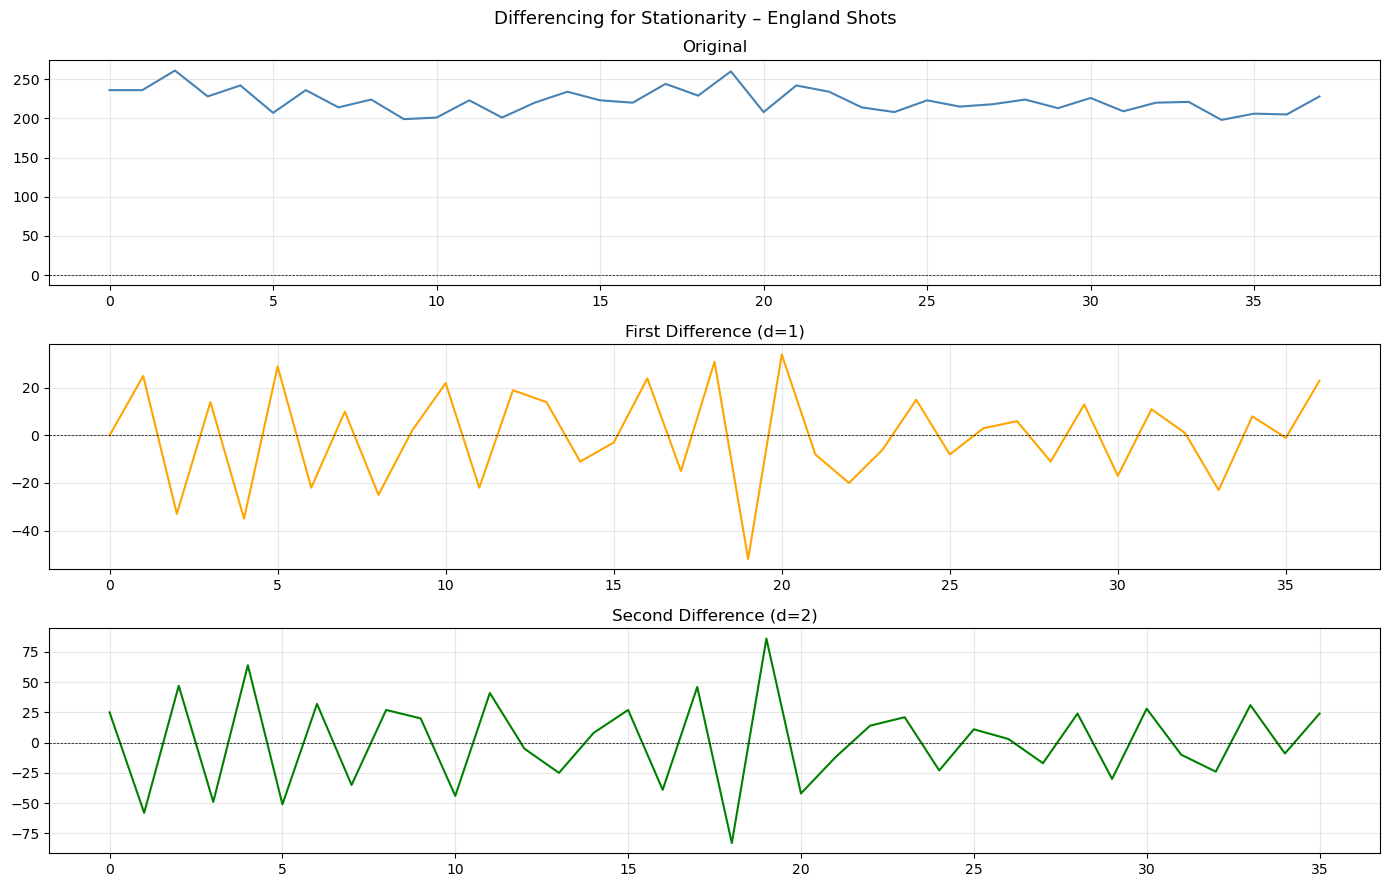

In [15]:
# ── 5f: First differencing (remove trend for stationarity) ───────────────────
y_diff1 = np.diff(y, n=1)
y_diff2 = np.diff(y, n=2)

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
axes[0].plot(y,       color='steelblue'); axes[0].set_title('Original');
axes[1].plot(y_diff1, color='orange');   axes[1].set_title('First Difference (d=1)');
axes[2].plot(y_diff2, color='green');    axes[2].set_title('Second Difference (d=2)');
for ax in axes:
    ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
    ax.grid(alpha=0.3)
plt.suptitle('Differencing for Stationarity – England Shots', fontsize=13)
plt.tight_layout()
plt.show()


---
## BLOCK 6: Task 2 – Temporal Autocorrelation & Stationarity Analysis

ValueError: Can only compute partial correlations for lags up to 50% of the sample size. The requested nlags 20 must be < 19.

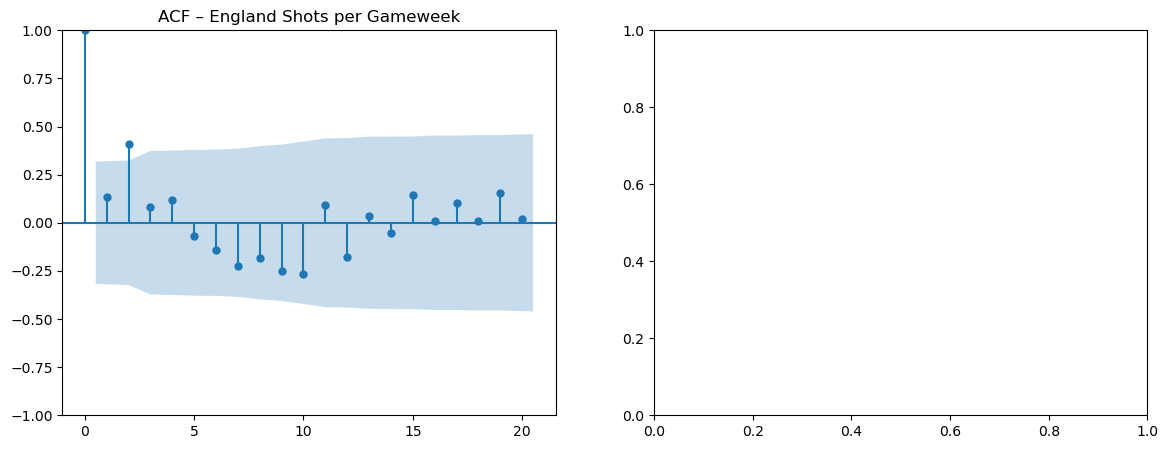

In [16]:
# ── 6a: ACF and PACF plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(y, lags=20, ax=axes[0], title='ACF – England Shots per Gameweek')
plot_pacf(y, lags=20, ax=axes[1], title='PACF – England Shots per Gameweek')
plt.tight_layout()
plt.show()

print('ACF: Shows correlation of series with its own lags.')
print('PACF: Shows direct correlation at each lag (removing intermediate effects).')
print('Spikes outside blue bands indicate significant autocorrelation at those lags.')


In [ ]:
# ── 6b: ACF/PACF on differenced series ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(y_diff1, lags=20, ax=axes[0],
         title='ACF – First-Differenced Series')
plot_pacf(y_diff1, lags=20, ax=axes[1],
          title='PACF – First-Differenced Series')
plt.tight_layout()
plt.show()


In [ ]:
# ── 6c: ACF/PACF for all leagues (shots per gameweek) ────────────────────────
fig, axes = plt.subplots(6, 2, figsize=(16, 24))
for i, league in enumerate(LEAGUES.keys()):
    ts = build_gameweek_series(league)['count'].values
    nlags = min(15, len(ts)//3)
    plot_acf(ts,  lags=nlags, ax=axes[i][0], title=f'{league} – ACF')
    plot_pacf(ts, lags=nlags, ax=axes[i][1], title=f'{league} – PACF')
plt.suptitle('ACF & PACF – Shots per Gameweek (All Leagues)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# ── 6d: ADF Test (Augmented Dickey-Fuller) – Stationarity ────────────────────
def run_adf(series, name):
    clean = series[~np.isnan(series)]
    result = adfuller(clean)
    print(f'  {name}')
    print(f'    ADF Statistic : {result[0]:.4f}')
    print(f'    p-value       : {result[1]:.4f}')
    print(f'    Critical (5%) : {result[4]["5%"]:.4f}')
    verdict = 'STATIONARY' if result[1] < 0.05 else 'NON-STATIONARY'
    print(f'    Result        : {verdict}')
    print()
    return result[1]

print('=== ADF Test Results (H0: series has unit root = non-stationary) ===')
print()
print('--- England Shots per Gameweek ---')
p_orig = run_adf(y,       'Original series')
p_d1   = run_adf(y_diff1, '1st difference')
p_d2   = run_adf(y_diff2, '2nd difference')

print('--- All Leagues (original series) ---')
for league in LEAGUES.keys():
    ts = build_gameweek_series(league)['count'].values
    run_adf(ts, league)


In [ ]:
# ── 6e: KPSS Test – Stationarity (complementary to ADF) ──────────────────────
def run_kpss(series, name):
    clean = series[~np.isnan(series)]
    result = kpss(clean, regression='c', nlags='auto')
    print(f'  {name}')
    print(f'    KPSS Statistic : {result[0]:.4f}')
    print(f'    p-value        : {result[1]:.4f}')
    verdict = 'NON-STATIONARY' if result[1] < 0.05 else 'STATIONARY'
    print(f'    Result         : {verdict}')
    print()

print('=== KPSS Test Results (H0: series IS stationary) ===')
print()
print('--- England Shots per Gameweek ---')
run_kpss(y,       'Original series')
run_kpss(y_diff1, '1st difference')

print('--- All Leagues ---')
for league in LEAGUES.keys():
    ts = build_gameweek_series(league)['count'].values
    run_kpss(ts, league)


In [ ]:
# ── 6f: Lag plot (visual autocorrelation check) ───────────────────────────────
from pandas.plotting import lag_plot

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for lag, ax in zip([1, 2, 5, 10], axes):
    lag_plot(pd.Series(y), lag=lag, ax=ax)
    ax.set_title(f'Lag Plot (lag={lag})')
plt.suptitle('Lag Plots – England Shots per Gameweek', fontsize=13)
plt.tight_layout()
plt.show()
print('Diagonal pattern = positive autocorrelation at that lag.')


---
## BLOCK 7: Task 3 – Temporal Regression Models (ARIMA + Linear)
### Sub-task A: Linear Regression Models

In [ ]:
# ── 7a: Simple Linear Regression (trend model) ───────────────────────────────
# y = shots per gameweek | x = gameweek index (time)
X_t = gw_ts['gameweek'].values.reshape(-1, 1)
y_t = gw_ts['count'].values

# 80/20 holdout split
split = int(len(y_t) * 0.8)
X_train, X_test = X_t[:split], X_t[split:]
y_train, y_test = y_t[:split], y_t[split:]

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

plt.figure(figsize=(14, 5))
plt.plot(gw_ts['gameweek'][:split], y_train, label='Train', color='steelblue')
plt.plot(gw_ts['gameweek'][split:], y_test,  label='Test (actual)', color='orange')
plt.plot(gw_ts['gameweek'][split:], y_pred_lr, label='Linear Regression Forecast',
         color='red', linestyle='--', linewidth=2)
plt.axvline(gw_ts['gameweek'].iloc[split], color='gray', linestyle=':', label='Train/Test split')
plt.title('Linear Regression Forecast – England Shots per Gameweek', fontsize=13)
plt.xlabel('Gameweek')
plt.ylabel('Shots')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Linear Regression → MAE: {mae_lr:.2f} | RMSE: {rmse_lr:.2f}')


In [ ]:
# ── 7b: Polynomial Regression (degree 3) ─────────────────────────────────────
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

pr = LinearRegression()
pr.fit(X_train_poly, y_train)
y_pred_poly = pr.predict(X_test_poly)

mae_poly  = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

plt.figure(figsize=(14, 5))
plt.plot(gw_ts['gameweek'][:split], y_train, label='Train', color='steelblue')
plt.plot(gw_ts['gameweek'][split:], y_test,  label='Test (actual)', color='orange')
plt.plot(gw_ts['gameweek'][split:], y_pred_poly, label='Poly Regression (deg=3)',
         color='purple', linestyle='--', linewidth=2)
plt.title('Polynomial Regression Forecast – England Shots per Gameweek', fontsize=13)
plt.xlabel('Gameweek')
plt.ylabel('Shots')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Polynomial Regression → MAE: {mae_poly:.2f} | RMSE: {rmse_poly:.2f}')


In [ ]:
# ── 7c: Multi-feature Linear Regression (match level) ────────────────────────
# Features: gameweek index, passes, duels → predict shots
eng_mt_clean = eng_mt.dropna(subset=['shots','passes','duels']).copy()
eng_mt_clean = eng_mt_clean.sort_values('date').reset_index(drop=True)
eng_mt_clean['gw_idx'] = range(len(eng_mt_clean))

features = ['gw_idx', 'passes', 'duels', 'total_goals']
Xm = eng_mt_clean[features].values
ym = eng_mt_clean['shots'].values

split_m = int(len(ym) * 0.8)
Xm_train, Xm_test = Xm[:split_m], Xm[split_m:]
ym_train, ym_test = ym[:split_m], ym[split_m:]

mlr = LinearRegression()
mlr.fit(Xm_train, ym_train)
ym_pred = mlr.predict(Xm_test)

mae_mlr  = mean_absolute_error(ym_test, ym_pred)
rmse_mlr = np.sqrt(mean_squared_error(ym_test, ym_pred))

print('=== Multi-feature Linear Regression – England Match Level ===')
print(f'Features: {features}')
print(f'MAE: {mae_mlr:.2f} | RMSE: {rmse_mlr:.2f}')
print('Coefficients:', dict(zip(features, mlr.coef_.round(4))))

plt.figure(figsize=(12, 4))
plt.plot(ym_test, label='Actual', color='orange')
plt.plot(ym_pred, label='Predicted', color='blue', linestyle='--')
plt.title('Multi-feature Linear Regression – Shots per Match (Test Set)', fontsize=13)
plt.xlabel('Match Index (Test Set)')
plt.ylabel('Shots')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Sub-task B: ARIMA Models

In [ ]:
# ── 7d: ARIMA(1,1,1) – baseline ───────────────────────────────────────────────
# Use England shots per gameweek
# Split: 80% train, 20% test
split = int(len(y_t) * 0.8)
y_train_a = y_t[:split]
y_test_a  = y_t[split:]
n_test = len(y_test_a)

# Fit ARIMA(1,1,1)
arima_111 = ARIMA(y_train_a, order=(1,1,1))
arima_111_fit = arima_111.fit()
print(arima_111_fit.summary())


In [ ]:
# ── 7e: ARIMA(2,1,2) ─────────────────────────────────────────────────────────
arima_212 = ARIMA(y_train_a, order=(2,1,2))
arima_212_fit = arima_212.fit()
print(arima_212_fit.summary())


In [ ]:
# ── 7f: ARIMA(1,0,1) – on stationary series ───────────────────────────────────
arima_101 = ARIMA(y_train_a, order=(1,0,1))
arima_101_fit = arima_101.fit()
print(arima_101_fit.summary())


In [ ]:
# ── 7g: Forecast all three ARIMA models on test set ──────────────────────────
models = {
    'ARIMA(1,1,1)': arima_111_fit,
    'ARIMA(2,1,2)': arima_212_fit,
    'ARIMA(1,0,1)': arima_101_fit,
}

results = []
plt.figure(figsize=(14, 6))
plt.plot(range(len(y_train_a)), y_train_a, color='steelblue', label='Train')
plt.plot(range(len(y_train_a), len(y_t)), y_test_a,
         color='orange', linewidth=2, label='Test (actual)')

colors_arima = ['red','purple','green']
for (name, fit), color in zip(models.items(), colors_arima):
    forecast = fit.forecast(steps=n_test)
    mae  = mean_absolute_error(y_test_a, forecast)
    rmse = np.sqrt(mean_squared_error(y_test_a, forecast))
    aic  = fit.aic
    results.append({'Model': name, 'MAE': round(mae,2), 'RMSE': round(rmse,2), 'AIC': round(aic,2)})
    plt.plot(range(len(y_train_a), len(y_t)), forecast,
             linestyle='--', linewidth=2, color=color, label=f'{name} (MAE={mae:.1f})')

plt.title('ARIMA Forecasts – England Shots per Gameweek', fontsize=13)
plt.xlabel('Gameweek Index')
plt.ylabel('Shot Count')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
print('\n=== ARIMA Model Comparison ===')
print(results_df.to_string(index=False))


In [ ]:
# ── 7h: SARIMA (Seasonal ARIMA) ──────────────────────────────────────────────
# Add seasonal component: period=5 (repeating every 5 gameweeks)
sarima = SARIMAX(y_train_a, order=(1,1,1), seasonal_order=(1,0,1,5))
sarima_fit = sarima.fit(disp=False)

sarima_forecast = sarima_fit.forecast(steps=n_test)
mae_sarima  = mean_absolute_error(y_test_a, sarima_forecast)
rmse_sarima = np.sqrt(mean_squared_error(y_test_a, sarima_forecast))

print(sarima_fit.summary())
print(f'\nSARIMA(1,1,1)(1,0,1,5) → MAE: {mae_sarima:.2f} | RMSE: {rmse_sarima:.2f} | AIC: {sarima_fit.aic:.2f}')


In [ ]:
# ── 7i: ARIMA on all leagues ──────────────────────────────────────────────────
print('=== ARIMA(1,1,1) across all leagues – Shots per Gameweek ===')
league_arima_results = []

for league in LEAGUES.keys():
    ts = build_gameweek_series(league)['count'].values
    if len(ts) < 10:
        print(f'{league}: too few data points, skipping')
        continue
    sp = int(len(ts) * 0.8)
    tr, te = ts[:sp], ts[sp:]
    try:
        fit = ARIMA(tr, order=(1,1,1)).fit()
        fc  = fit.forecast(steps=len(te))
        mae  = mean_absolute_error(te, fc)
        rmse = np.sqrt(mean_squared_error(te, fc))
        league_arima_results.append({
            'League': league, 'MAE': round(mae,2),
            'RMSE': round(rmse,2), 'AIC': round(fit.aic,2)
        })
    except Exception as e:
        print(f'{league}: ARIMA failed – {e}')

league_results_df = pd.DataFrame(league_arima_results)
print(league_results_df.to_string(index=False))


---
## BLOCK 8: Model Comparison & Residual Diagnostics

In [ ]:
# ── 8a: Residual analysis for best ARIMA model ────────────────────────────────
best_model = arima_111_fit  # change if another model had lower AIC

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Residuals over time
axes[0,0].plot(best_model.resid, color='steelblue')
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title('Residuals Over Time')

# Residual histogram
axes[0,1].hist(best_model.resid, bins=15, color='steelblue', edgecolor='white')
axes[0,1].set_title('Residual Distribution')

# ACF of residuals
plot_acf(best_model.resid, lags=15, ax=axes[1,0],
         title='ACF of Residuals')

# QQ plot
from scipy import stats
stats.probplot(best_model.resid, plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot of Residuals')

plt.suptitle('Residual Diagnostics – ARIMA(1,1,1) England Shots', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ── 8b: Final model comparison summary ───────────────────────────────────────
all_results = pd.DataFrame([
    {'Model': 'Linear Regression',         'MAE': round(mae_lr,2),   'RMSE': round(rmse_lr,2),   'AIC': '-'},
    {'Model': 'Polynomial Regression(d=3)','MAE': round(mae_poly,2), 'RMSE': round(rmse_poly,2), 'AIC': '-'},
    {'Model': 'ARIMA(1,1,1)',              'MAE': results_df.loc[0,'MAE'], 'RMSE': results_df.loc[0,'RMSE'], 'AIC': results_df.loc[0,'AIC']},
    {'Model': 'ARIMA(2,1,2)',              'MAE': results_df.loc[1,'MAE'], 'RMSE': results_df.loc[1,'RMSE'], 'AIC': results_df.loc[1,'AIC']},
    {'Model': 'ARIMA(1,0,1)',              'MAE': results_df.loc[2,'MAE'], 'RMSE': results_df.loc[2,'RMSE'], 'AIC': results_df.loc[2,'AIC']},
    {'Model': 'SARIMA(1,1,1)(1,0,1,5)',   'MAE': round(mae_sarima,2), 'RMSE': round(rmse_sarima,2), 'AIC': round(sarima_fit.aic,2)},
])

print('=' * 60)
print('   FINAL MODEL COMPARISON – England Shots per Gameweek')
print('=' * 60)
print(all_results.to_string(index=False))
print()
print('Best model (lowest MAE):', all_results.loc[all_results['MAE'].astype(str).str.replace('-','999').astype(float).idxmin(), 'Model'])


In [ ]:
# ── 8c: Forecast visualization – all models on one plot ──────────────────────
arima_forecasts = {}
for name, fit in models.items():
    arima_forecasts[name] = fit.forecast(steps=n_test)
arima_forecasts['SARIMA(1,1,1)(1,0,1,5)'] = sarima_forecast

plt.figure(figsize=(14, 6))
plt.plot(range(len(y_train_a)), y_train_a, color='steelblue', label='Train', linewidth=1.5)
plt.plot(range(len(y_train_a), len(y_t)), y_test_a, color='black', linewidth=2, label='Actual Test')

fc_colors = ['red','purple','green','brown']
for (name, fc), col in zip(arima_forecasts.items(), fc_colors):
    plt.plot(range(len(y_train_a), len(y_t)), fc,
             linestyle='--', linewidth=1.5, color=col, label=name)

plt.axvline(len(y_train_a)-1, color='gray', linestyle=':', linewidth=1)
plt.title('All Model Forecasts vs Actual – England Shots per Gameweek', fontsize=13)
plt.xlabel('Gameweek Index')
plt.ylabel('Shot Count')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## BLOCK 9: Cross-League Temporal Comparison Summary

In [ ]:
# ── 9a: Stationarity summary table ───────────────────────────────────────────
print('=== ADF Stationarity Summary – All Leagues (Shots per Gameweek) ===')
stat_rows = []
for league in LEAGUES.keys():
    ts = build_gameweek_series(league)['count'].values
    adf_p  = adfuller(ts)[1]
    kpss_p = kpss(ts, regression='c', nlags='auto')[1]
    acf_1  = acf(ts, nlags=1)[1]
    stat_rows.append({
        'League': league,
        'Length': len(ts),
        'Mean': round(ts.mean(), 1),
        'Std': round(ts.std(), 1),
        'ADF_p': round(adf_p, 4),
        'KPSS_p': round(kpss_p, 4),
        'ACF_lag1': round(acf_1, 4),
        'ADF_Stationary': 'Yes' if adf_p < 0.05 else 'No',
    })

stat_df = pd.DataFrame(stat_rows)
print(stat_df.to_string(index=False))


In [ ]:
# ── 9b: Cross-league ARIMA comparison bar chart ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

league_results_df.plot(x='League', y='MAE', kind='bar', ax=axes[0],
                        color='steelblue', edgecolor='white', legend=False)
axes[0].set_title('ARIMA(1,1,1) MAE – All Leagues')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=30)

league_results_df.plot(x='League', y='AIC', kind='bar', ax=axes[1],
                        color='crimson', edgecolor='white', legend=False)
axes[1].set_title('ARIMA(1,1,1) AIC – All Leagues')
axes[1].set_ylabel('AIC')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('ARIMA Model Performance Across Leagues', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ── 9c: Final printed summary ─────────────────────────────────────────────────
print('=' * 60)
print('     A2 TEMPORAL ANALYSIS – COMPLETE SUMMARY')
print('=' * 60)
print()
print('── Dataset ──────────────────────────────────────────────')
for league in LEAGUES.keys():
    n = len(full_df[full_df['league']==league])
    m = len(all_matches[league])
    print(f'  {league:12s}: {n:>7,} events | {m:>3} matches')
print()
print('── Stationarity (ADF Test) ──────────────────────────────')
print(stat_df[['League','ADF_p','ADF_Stationary']].to_string(index=False))
print()
print('── ARIMA(1,1,1) Forecasting Performance ─────────────────')
print(league_results_df.to_string(index=False))
print()
print('── England – All Models Compared ────────────────────────')
print(all_results.to_string(index=False))
print('=' * 60)
